In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
no_atten = pd.read_csv(r'0dBAtten.csv', skiprows=1)
atten_30 = pd.read_csv(r'30dBAtten.csv', skiprows=1)

In [6]:
no_atten
atten_30

,#,HZ,S,RI,R,50
0,200000000,-0.095464,-0.015048,-0.032832,0.007832,0
1,201000000,-0.095521,-0.014734,-0.032732,0.008431,0
2,202000000,-0.095682,-0.014486,-0.032567,0.008969,0
3,203000000,-0.095834,-0.014201,-0.032355,0.009563,0
4,204000000,-0.095936,-0.013962,-0.032243,0.010107,0
...,...,...,...,...,...,...
196,396000000,-0.054959,-0.025555,0.030942,-0.017480,0
197,397000000,-0.055032,-0.026068,0.030633,-0.018023,0
198,398000000,-0.055363,-0.026575,0.030342,-0.018565,0
199,399000000,-0.055347,-0.027142,0.029975,-0.019118,0


In [8]:
frequency_0 = no_atten['#']
power_dbm_0 = no_atten['HZ']

frequency_30 = atten_30['#']
power_dbm_30 = atten_30['HZ']

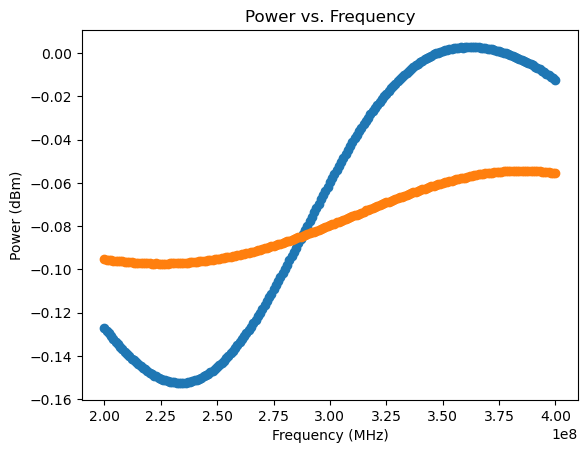

In [9]:
plt.title("Power vs. Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")
plt.scatter(frequency_0, power_dbm_0)
plt.scatter(frequency_30, power_dbm_30)
plt.show()

In [13]:
def linear_fit(x, m, b):
    return m*x + b

popt0, pcov0 = curve_fit(linear_fit, frequency_0, 
                       power_dbm_0, p0=[-1, 4e-5])

print(popt0)
print(pcov0)

popt30, pcov30 = curve_fit(linear_fit, frequency_30, 
                       power_dbm_30, p0=[-1, 4e-5])

print(popt30)
print(pcov30)

[ 1.00010869e-09 -3.69147440e-01]
[[ 6.09155934e-22 -1.82746781e-13]
 [-1.82746781e-13  5.68748594e-05]]
[ 2.76845226e-10 -1.60661422e-01]
[[ 1.87048456e-23 -5.61145371e-15]
 [-5.61145371e-15  1.74640911e-06]]


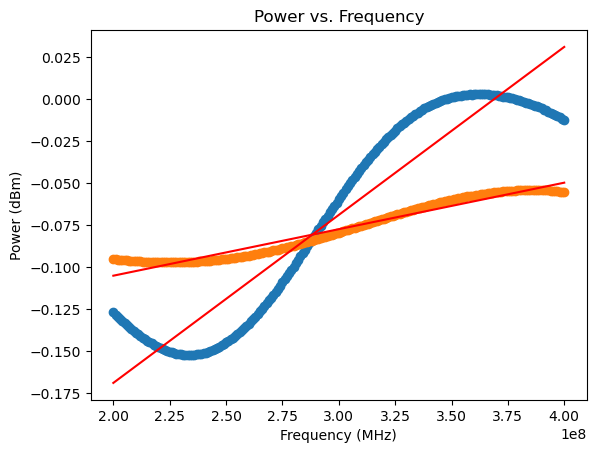

In [14]:
plt.title("Power vs. Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")
plt.scatter(frequency_0, power_dbm_0)
plt.scatter(frequency_30, power_dbm_30)
plt.plot(frequency_0, linear_fit(frequency_0, popt0[0],
                                        popt0[1]), color='red')
plt.plot(frequency_30, linear_fit(frequency_30, popt30[0],
                                        popt30[1]), color='red')
plt.show()